# Laboratorio 2 - Deep Learning (LSTM + catch22)

Entrega final. Se trabajan las dos series mensuales del laboratorio 1 (total de viajeros y vía
aérea): modelos LSTM con tuneo, comparación con SARIMA, y análisis de muchas series con catch22.
Framework de DL: PyTorch (TensorFlow no tiene build para Python 3.14).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pycatch22
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

torch.manual_seed(0)
np.random.seed(0)
BASE = Path("..")

## 1. Datos

Se regeneran las series y el split desde `src/preparar_datos.py`.

In [2]:
%run ../src/preparar_datos.py

filas limpias: (137642, 14)
serie: 2009-01-01 - 2026-06-01
corte train/test en: 2021-04-01


In [3]:
def cargar(nombre):
    tr = pd.read_csv(BASE / f"data/processed/train_{nombre}.csv", index_col=0, parse_dates=True).iloc[:, 0]
    te = pd.read_csv(BASE / f"data/processed/test_{nombre}.csv", index_col=0, parse_dates=True).iloc[:, 0]
    return tr, te

series = {"total": cargar("total"), "aerea": cargar("aerea")}
for n, (tr, te) in series.items():
    print(n, "-> train:", len(tr), "test:", len(te))

total -> train: 147 test: 63
aerea -> train: 147 test: 63


## 2. LSTM

Preprocesamiento: `log1p` para estabilizar varianza + escalado min-max con el train. La red recibe
ventanas de `lookback` meses y predice el siguiente. El pronóstico sobre el test es recursivo.

In [4]:
def hacer_ventanas(arr, lookback):
    X, y = [], []
    for i in range(len(arr) - lookback):
        X.append(arr[i:i + lookback])
        y.append(arr[i + lookback])
    return np.array(X), np.array(y)


class LSTM(nn.Module):
    def __init__(self, hidden, layers, in_size=1):
        super().__init__()
        self.lstm = nn.LSTM(in_size, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def entrenar_evaluar(train, test, lookback, hidden, layers, epochs=250, lr=0.01, extra=None):
    tr_log = np.log1p(train.values)
    lo, hi = tr_log.min(), tr_log.max()
    escalar = lambda a: (a - lo) / (hi - lo)
    invertir = lambda a: np.expm1(a * (hi - lo) + lo)

    tr_s = escalar(tr_log)
    X, y = hacer_ventanas(tr_s, lookback)
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    yt = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    # extra: features catch22 constantes que se agregan como canales de entrada (para 2.14)
    if extra is not None:
        e = torch.tensor(extra, dtype=torch.float32)
        Xt = torch.cat([Xt, e.view(1, 1, -1).expand(Xt.shape[0], lookback, -1)], dim=-1)

    torch.manual_seed(0)
    modelo = LSTM(hidden, layers, in_size=Xt.shape[-1])
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    modelo.train()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(modelo(Xt), yt)
        loss.backward()
        opt.step()

    modelo.eval()
    ventana = list(tr_s[-lookback:])
    preds = []
    with torch.no_grad():
        for _ in range(len(test)):
            w = torch.tensor(ventana[-lookback:], dtype=torch.float32).view(1, lookback, 1)
            if extra is not None:
                w = torch.cat([w, e.view(1, 1, -1).expand(1, lookback, -1)], dim=-1)
            p = modelo(w).item()
            preds.append(p)
            ventana.append(p)

    pred = invertir(np.array(preds))
    rmse = float(np.sqrt(np.mean((pred - test.values) ** 2)))
    mae = float(np.mean(np.abs(pred - test.values)))
    return pred, rmse, mae

### Tuneo de hiperparámetros

Grilla de 5 configuraciones por serie (10 modelos) variando ventana, neuronas y capas. Se compara
por RMSE y MAE sobre el test.

In [5]:
grilla = [
    dict(lookback=12, hidden=16, layers=1),
    dict(lookback=12, hidden=32, layers=1),
    dict(lookback=12, hidden=32, layers=2),
    dict(lookback=24, hidden=32, layers=1),
    dict(lookback=24, hidden=64, layers=2),
]

resultados = {}
predicciones = {}
for nombre, (train, test) in series.items():
    filas = []
    for cfg in grilla:
        pred, rmse, mae = entrenar_evaluar(train, test, **cfg)
        filas.append({**cfg, "rmse": rmse, "mae": mae})
        predicciones[(nombre, tuple(cfg.values()))] = pred
    tabla = pd.DataFrame(filas).sort_values("rmse").reset_index(drop=True)
    resultados[nombre] = tabla
    print(f"\n=== serie {nombre} ===")
    print(tabla.to_string(index=False))


=== serie total ===
 lookback  hidden  layers          rmse          mae
       12      32       2  79606.326429 69607.355912
       24      64       2  80292.480988 70144.106343
       24      32       1  88652.549059 78514.451791
       12      32       1  94721.789307 84725.747444
       12      16       1 104946.746081 93323.535474



=== serie aerea ===
 lookback  hidden  layers         rmse          mae
       24      64       2 27926.469705 23039.340642
       12      16       1 28961.834404 24051.180354
       12      32       1 31487.400724 26459.330701
       24      32       1 34236.616026 28991.251440
       12      32       2 44276.828785 37247.551418


### Mejor modelo por serie

In [6]:
mejores = {}
for nombre, tabla in resultados.items():
    best = tabla.iloc[0]
    mejores[nombre] = best
    print(f"{nombre}: lookback={int(best.lookback)} hidden={int(best.hidden)} "
          f"layers={int(best.layers)} -> RMSE={best.rmse:.1f} MAE={best.mae:.1f}")

total: lookback=12 hidden=32 layers=2 -> RMSE=79606.3 MAE=69607.4
aerea: lookback=24 hidden=64 layers=2 -> RMSE=27926.5 MAE=23039.3


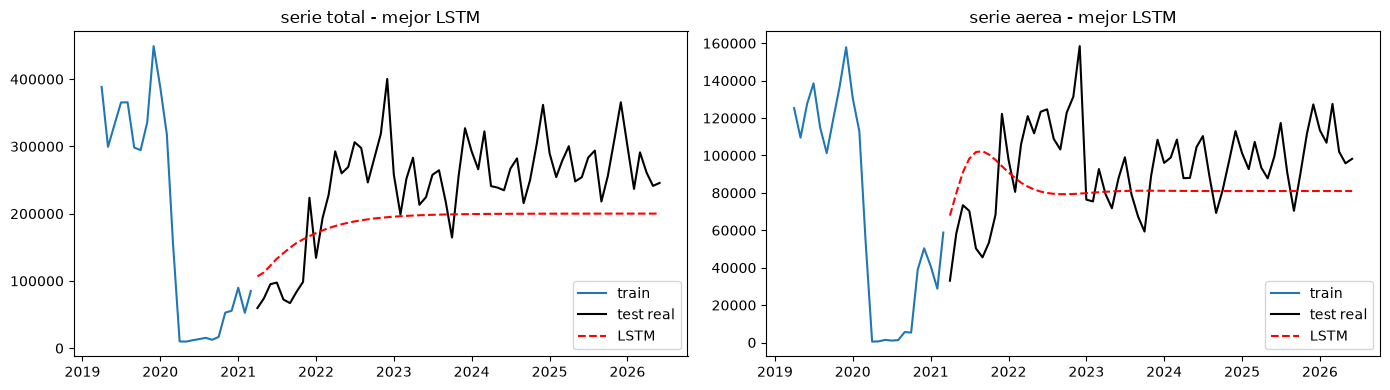

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (nombre, (train, test)) in zip(axes, series.items()):
    best = mejores[nombre]
    clave = (nombre, (int(best.lookback), int(best.hidden), int(best.layers)))
    ax.plot(train.index[-24:], train.values[-24:], label="train")
    ax.plot(test.index, test.values, label="test real", color="black")
    ax.plot(test.index, predicciones[clave], label="LSTM", color="red", ls="--")
    ax.set_title(f"serie {nombre} - mejor LSTM")
    ax.legend()
plt.tight_layout()
plt.show()

## 3. Comparación con SARIMA

Como referencia del enfoque clásico se ajusta un SARIMA sobre el log de cada serie. Del análisis del
laboratorio 1 se sabe que las series necesitan una diferencia regular y una estacional (s=12). Se usa
el modelo airline `(0,1,1)(0,1,1,12)`, que es el más estable (con término AR estacional el pronóstico
de la serie aérea diverge). Se compara contra el mejor LSTM de cada serie.

In [8]:
def sarima_eval(train, test, order=(0, 1, 1), seasonal=(0, 1, 1, 12)):
    tr_log = np.log1p(train.values)
    m = SARIMAX(tr_log, order=order, seasonal_order=seasonal,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pred = np.expm1(np.asarray(m.forecast(len(test))))
    rmse = float(np.sqrt(np.mean((pred - test.values) ** 2)))
    mae = float(np.mean(np.abs(pred - test.values)))
    return pred, rmse, mae


comparacion = []
sarima_pred = {}
for nombre, (train, test) in series.items():
    b = mejores[nombre]
    pred, s_rmse, s_mae = sarima_eval(train, test)
    sarima_pred[nombre] = pred
    comparacion.append({"serie": nombre,
                        "LSTM_rmse": round(b.rmse, 1), "SARIMA_rmse": round(s_rmse, 1),
                        "LSTM_mae": round(b.mae, 1), "SARIMA_mae": round(s_mae, 1),
                        "mejor": "LSTM" if b.rmse < s_rmse else "SARIMA"})
tabla_comp = pd.DataFrame(comparacion)
print(tabla_comp.to_string(index=False))

serie  LSTM_rmse  SARIMA_rmse  LSTM_mae  SARIMA_mae mejor
total    79606.3     228724.6   69607.4    213845.9  LSTM
aerea    27926.5      72350.0   23039.3     68082.5  LSTM


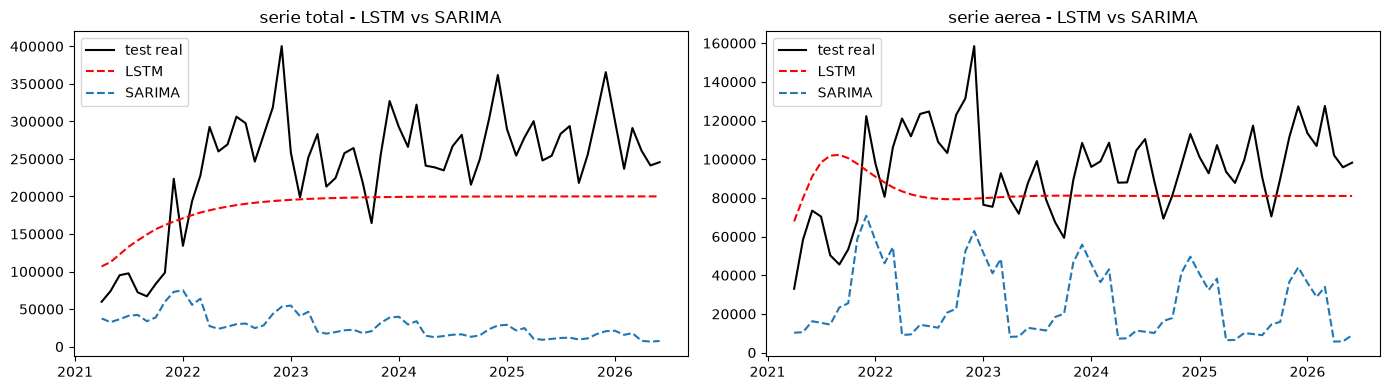

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (nombre, (train, test)) in zip(axes, series.items()):
    best = mejores[nombre]
    clave = (nombre, (int(best.lookback), int(best.hidden), int(best.layers)))
    ax.plot(test.index, test.values, label="test real", color="black")
    ax.plot(test.index, predicciones[clave], label="LSTM", color="red", ls="--")
    ax.plot(test.index, sarima_pred[nombre], label="SARIMA", color="tab:blue", ls="--")
    ax.set_title(f"serie {nombre} - LSTM vs SARIMA")
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Análisis con catch22

Se arma un panel de series mensuales por distintas categorías (vía, tipo de viajero, región,
frontera y país) y se extraen las 22 características de `catch22` de cada una. Con eso se hace PCA y
clustering para ver qué series se parecen entre sí.

In [10]:
clean = pd.read_csv(BASE / "data/processed/migracion_limpia.csv", parse_dates=["Fecha"])
idx = pd.date_range(clean["Fecha"].min(), clean["Fecha"].max(), freq="MS")

panel, categoria = {}, {}


def agregar(col, cat, valores):
    for v in valores:
        s = clean[clean[col] == v].groupby("Fecha")["Viajero"].sum().reindex(idx, fill_value=0)
        nombre = f"{cat}:{v}"
        panel[nombre] = s
        categoria[nombre] = cat


agregar("Vía", "via", ["Terrestre", "Aérea", "Marítima"])
agregar("Tipo de Viajero", "tipo", ["Turista", "Excursionista"])
agregar("Región", "region", clean.groupby("Región")["Viajero"].sum().nlargest(8).index)
agregar("Frontera", "frontera", clean.groupby("Frontera")["Viajero"].sum().nlargest(8).index)
agregar("País", "pais", clean.groupby("País")["Viajero"].sum().nlargest(10).index)

print("series en el panel:", len(panel))

series en el panel: 31


In [11]:
def features_catch22(serie):
    r = pycatch22.catch22_all(list(serie.values.astype(float)))
    return pd.Series(r["values"], index=r["names"])

feat = pd.DataFrame({n: features_catch22(s) for n, s in panel.items()}).T
feat = feat.dropna(axis=1)  # descarta features que salen NaN en alguna serie
print("matriz de features:", feat.shape)
feat.head()

matriz de features: (31, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
via:Terrestre,0.277301,-0.193022,9.572755,2.0,0.484160,-0.024702,0.933014,29.0,0.013774,3.0,...,0.055556,0.219048,0.328571,0.817693,6.0,1.781787,0.833333,0.857143,0.098175,0.615634
via:Aérea,-0.398224,-0.114663,6.590944,10.0,0.206212,-0.162779,0.956938,34.0,0.010204,11.0,...,0.071429,0.185714,0.323810,0.758284,5.0,2.000891,0.857143,0.857143,0.171806,0.738677
via:Marítima,-0.577057,-0.729479,41.892181,6.0,0.667090,-0.040471,0.449761,96.0,0.074074,7.0,...,0.014493,-0.552381,0.461905,0.945293,4.0,1.204569,0.166667,0.785714,0.024544,0.323401
tipo:Turista,-0.036878,0.224708,8.721277,2.0,0.266628,-0.070405,0.971292,30.0,0.013774,3.0,...,0.055556,0.152381,0.323810,0.794164,6.0,1.868443,0.857143,0.857143,0.147262,0.670087
tipo:Excursionista,-0.351261,-0.579081,10.624822,15.0,0.510622,-0.042198,0.904306,30.0,0.005510,52.0,...,0.052632,0.266667,0.319048,0.853298,4.0,1.793196,0.761905,0.857143,0.098175,0.554374


### PCA y clustering

Se estandarizan las 22 features, se proyecta a 2D con PCA y se agrupa con KMeans (k por silueta).

In [12]:
X = StandardScaler().fit_transform(feat.values)
pca = PCA(n_components=2).fit(X)
proj = pca.transform(X)

ks = range(2, 7)
sils = [silhouette_score(X, KMeans(k, n_init=10, random_state=0).fit_predict(X)) for k in ks]
k = list(ks)[int(np.argmax(sils))]
labels = KMeans(k, n_init=10, random_state=0).fit_predict(X)
print(f"k elegido por silueta: {k}  (var. explicada PC1+PC2 = {pca.explained_variance_ratio_[:2].sum():.2f})")

feat_pca = pd.DataFrame(proj, index=feat.index, columns=["PC1", "PC2"])
feat_pca["cluster"] = labels
feat_pca["categoria"] = [categoria[n] for n in feat.index]

k elegido por silueta: 2  (var. explicada PC1+PC2 = 0.47)


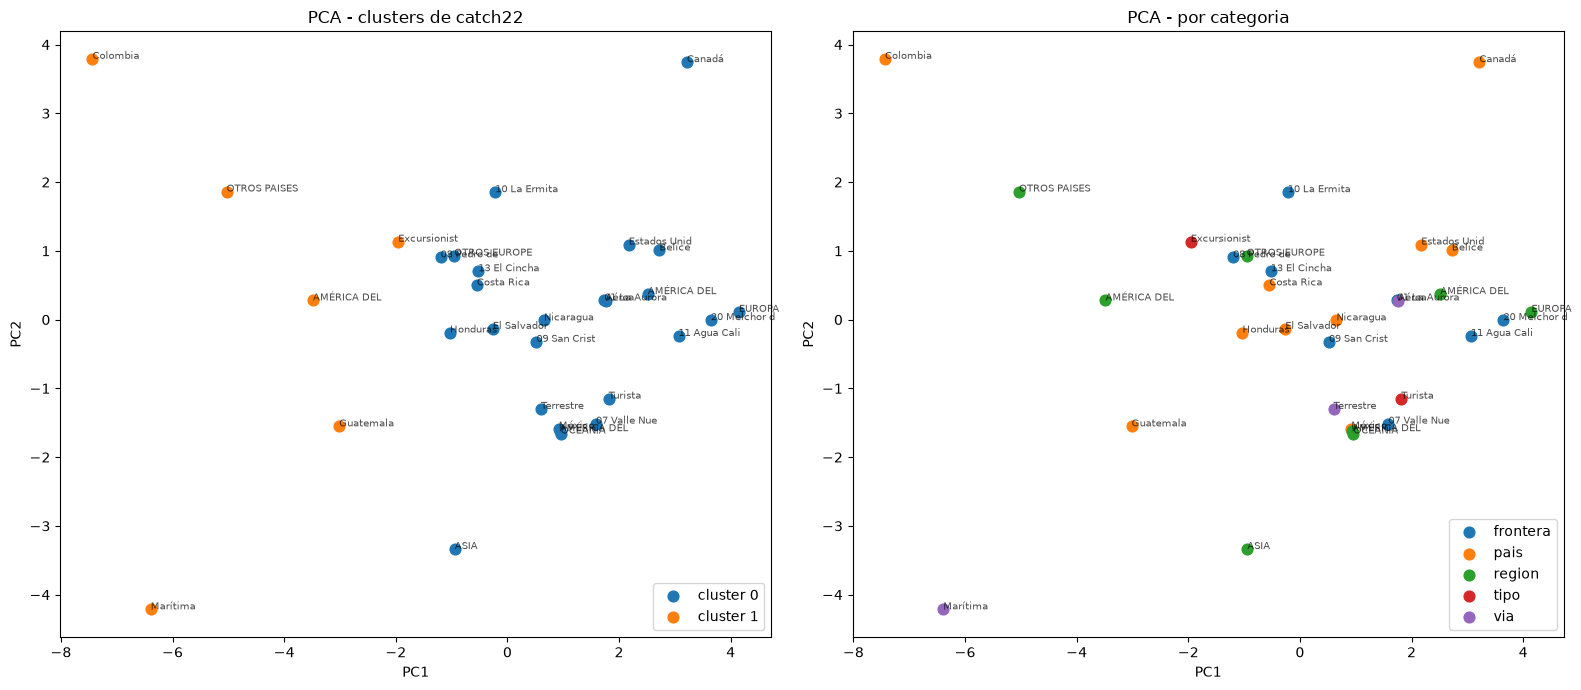

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# coloreado por cluster
for cl in sorted(set(labels)):
    sub = feat_pca[feat_pca.cluster == cl]
    axes[0].scatter(sub.PC1, sub.PC2, label=f"cluster {cl}", s=60)
axes[0].set_title("PCA - clusters de catch22")
axes[0].legend()
# coloreado por categoria
for cat in sorted(set(categoria.values())):
    sub = feat_pca[feat_pca.categoria == cat]
    axes[1].scatter(sub.PC1, sub.PC2, label=cat, s=60)
axes[1].set_title("PCA - por categoria")
axes[1].legend()
for ax in axes:
    for n, row in feat_pca.iterrows():
        ax.annotate(n.split(":")[1][:12], (row.PC1, row.PC2), fontsize=7, alpha=0.7)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

### Características más importantes (2.8)

Se ven las features con mayor carga (loading) en PC1 y PC2.

In [14]:
loadings = pd.DataFrame(pca.components_.T, index=feat.columns, columns=["PC1", "PC2"])
print("Top features por |carga| en PC1:")
print(loadings.PC1.abs().sort_values(ascending=False).head(5).to_string())
print("\nTop features por |carga| en PC2:")
print(loadings.PC2.abs().sort_values(ascending=False).head(5).to_string())

Top features por |carga| en PC1:
FC_LocalSimple_mean3_stderr         0.342490
SP_Summaries_welch_rect_area_5_1    0.307963
CO_HistogramAMI_even_2_5            0.301162
CO_f1ecac                           0.299069
SB_MotifThree_quantile_hh           0.285431

Top features por |carga| en PC2:
DN_OutlierInclude_p_001_mdrmd       0.459823
SB_BinaryStats_mean_longstretch1    0.337492
DN_OutlierInclude_n_001_mdrmd       0.324772
DN_HistogramMode_5                  0.316695
CO_FirstMin_ac                      0.244705


### Series más atípicas (2.11)

Distancia de cada serie al centroide global en el espacio estandarizado de features.

In [15]:
dist = np.linalg.norm(X - X.mean(axis=0), axis=1)
atipicas = pd.Series(dist, index=feat.index).sort_values(ascending=False)
print("Series mas atipicas:")
print(atipicas.head(5).to_string())

Series mas atipicas:
via:Marítima                            9.006697
pais:Colombia                           8.989528
pais:Canadá                             7.911831
region:OTROS PAISES DEL MUNDO           7.208725
frontera:13 El Cinchado / El Corinto    5.558522


### Composición de los clusters (2.9, 2.10)

Qué categorías caen en cada cluster, para ver si las series de una misma categoría se agrupan.

In [16]:
tabla_cl = feat_pca.reset_index().rename(columns={"index": "serie"})
print(pd.crosstab(tabla_cl.cluster, tabla_cl.categoria).to_string())
print()
for cl in sorted(set(labels)):
    miembros = [n.split(":", 1)[1] for n in feat_pca[feat_pca.cluster == cl].index]
    print(f"cluster {cl}: {miembros}")

categoria  frontera  pais  region  tipo  via
cluster                                     
0                 8     8       6     1    2
1                 0     2       2     1    1

cluster 0: ['Terrestre', 'Aérea', 'Turista', 'AMÉRICA DEL CENTRO', 'AMÉRICA DEL NORTE', 'EUROPA', 'OTROS EUROPEOS', 'ASIA', 'OCEANÍA', '01 La Aurora', '07 Valle Nuevo', '09 San Cristóbal', '08 Pedro de Alvarado', '10 La Ermita (Nueva Anguiatú)', '20 Melchor de Mencos', '13 El Cinchado / El Corinto', '11 Agua Caliente', 'El Salvador', 'Estados Unidos de América', 'Honduras', 'México', 'Belice', 'Costa Rica', 'Nicaragua', 'Canadá']
cluster 1: ['Marítima', 'Excursionista', 'AMÉRICA DEL SUR', 'OTROS PAISES DEL MUNDO', 'Guatemala', 'Colombia']


## 5. LSTM con características catch22 (2.14)

Se toma la serie total y se entrena un LSTM que, además de la ventana de valores, recibe como
entrada constante las primeras características de catch22 de la serie. Se compara con el mejor LSTM
"puro" de la serie total.

In [17]:
nombre = "total"
train, test = series[nombre]
best = mejores[nombre]
cfg = dict(lookback=int(best.lookback), hidden=int(best.hidden), layers=int(best.layers))

# catch22 sobre la serie de entrenamiento (escalada) -> primeras 5 features como extra
tr_log = np.log1p(train.values)
tr_s = (tr_log - tr_log.min()) / (tr_log.max() - tr_log.min())
extra = features_catch22(pd.Series(tr_s)).dropna().values[:5].astype(float)
extra = (extra - extra.mean()) / (extra.std() + 1e-9)

_, rmse_c22, mae_c22 = entrenar_evaluar(train, test, **cfg, extra=extra)
print(f"LSTM puro    -> RMSE={best.rmse:.1f}  MAE={best.mae:.1f}")
print(f"LSTM+catch22 -> RMSE={rmse_c22:.1f}  MAE={mae_c22:.1f}")

LSTM puro    -> RMSE=79606.3  MAE=69607.4
LSTM+catch22 -> RMSE=88111.5  MAE=77808.8
